# 04 — Tuning

**Objetivo:** Otimizar XGBoost vs RandomForest na mesma busca Optuna (40 trials, PR-AUC), treinar o pipeline final e otimizar o threshold para o trade-off de negócio recall/precision, avaliando no conjunto de teste intocado.

---

**Roteiro:**

1. Setup
2. Carregamento de dados
3. Executar o estudo Optuna
4. Treinamento do modelo vencedor
5. Otimização do threshold (trade-off de negócio)
6. Consolidação e visualização do threshold final
7. Persistir artefatos e pipeline final


### Etapa 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from src.config import CONFIG, CAMINHOS
from src.viz_config import aplicar_tema_seaborn, PALETTE, CORES

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

DADOS_PRO    = CAMINHOS.dados_processed
MODELS_DIR   = CAMINHOS.modelos
FIGURAS_DIR  = CAMINHOS.figures
RANDOM_STATE = CONFIG["dados"]["random_state"]

aplicar_tema_seaborn()
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\n✅ Setup configurado!\n")

print(f"SEED             : {RANDOM_STATE}")
print(f"FIGURAS          : {FIGURAS_DIR}")
print(f"MODELOS          : {MODELS_DIR}")
print(f"DADOS PROCESSADOS: {DADOS_PRO}")


✅ Setup configurado!

SEED             : 42
FIGURAS          : C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\reports\figures
MODELOS          : C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\models
DADOS PROCESSADOS: C:\Users\jas_t\Repo\Portfolios\credit_card_fraud\data\processed


### Etapa 2 - Carregamento de dados

### Estrutura da Etapa de Otimização

Esta etapa será organizada em quatro partes principais, com foco no refinamento dos modelos que apresentaram melhor desempenho na comparação inicial.

1. **Carregamento dos dados:**
   Leitura dos conjuntos de treino e teste previamente salvos, garantindo continuidade entre os notebooks.

2. **Reconstrução do pré-processador:**
   Recriação da estrutura de pré-processamento definida anteriormente, mantendo consistência no tratamento das variáveis.

3. **Validação cruzada estratificada:**
   Aplicação de **StratifiedKFold** para preservar a proporção de fraudes em cada fold. Para o **XGBoost**, será utilizado `scale_pos_weight`, calculado pela razão entre exemplos negativos e positivos, como estratégia de ajuste ao desbalanceamento.

4. **Otimização com Optuna:**
   Uso do **Optuna** para buscar os melhores hiperparâmetros dos modelos com melhor desempenho inicial: **XGBoost** e **Random Forest**.

In [2]:
X_train = pd.read_parquet(DADOS_PRO / "X_train.parquet")
y_train = pd.read_parquet(DADOS_PRO / "y_train.parquet").iloc[:, 0]

In [3]:
V_COLS = [c for c in X_train.columns if c.startswith("V")]

def make_preprocessor():
    """Cria o preprocessor: RobustScaler no Amount, V's passthrough.
    set_output('pandas') garante que a saída seja DataFrame (nomes de
    features preservados — essencial p/ SHAP e robustez no app)."""
    prep = ColumnTransformer(
        transformers=[
            ("amount", RobustScaler(), ["Amount"]),
            ("vs",     "passthrough",  V_COLS),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    prep.set_output(transform="pandas")
    return prep

_proc = make_preprocessor().fit_transform(X_train.head())
print(f"✅ Preprocessor produz: {type(_proc).__name__}")
print(f"   Colunas: {list(_proc.columns)}")

✅ Preprocessor produz: DataFrame
   Colunas: ['Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']


In [4]:
CV  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
spw = (y_train == 0).sum() / (y_train == 1).sum()

print(f"scale_pos_weight (XGB): {spw:.0f}")

scale_pos_weight (XGB): 599


In [5]:
N_TRIALS = 40

def objetivo(trial):
    modelo_tipo = trial.suggest_categorical("modelo", ["xgb", "rf"])
    if modelo_tipo == "xgb":
        clf = XGBClassifier(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 600),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 10),
            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3, log=True),
            subsample=trial.suggest_float("xgb_subsample", 0.6, 1.0),
            colsample_bytree=trial.suggest_float("xgb_colsample", 0.6, 1.0),
            scale_pos_weight=spw, eval_metric="aucpr",
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    else:
        clf = RandomForestClassifier(
            n_estimators=trial.suggest_int("rf_n_estimators", 100, 500),
            max_depth=trial.suggest_int("rf_max_depth", 5, 30),
            min_samples_split=trial.suggest_int("rf_min_split", 2, 20),
            min_samples_leaf=trial.suggest_int("rf_min_leaf", 1, 10),
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
        )
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=CV,
                             scoring="average_precision", n_jobs=-1)
    return scores.mean()

print(f"Optuna pronto ({N_TRIALS} trials)")
print(f"Otimizando: XGBoost vs RandomForest · métrica: PR-AUC")

Optuna pronto (40 trials)
Otimizando: XGBoost vs RandomForest · métrica: PR-AUC


### Etapa 3 - Executar o estudo Optuna

Após a execução da otimização com **Optuna**, será identificado o **melhor trial** com base na métrica principal do projeto: **PR-AUC**.

Essa etapa permite recuperar:

* o maior valor de PR-AUC obtido durante a busca;
* os hiperparâmetros associados ao melhor desempenho;
* o número do trial vencedor;
* a configuração final a ser utilizada no treinamento do modelo otimizado.

In [6]:
estudo = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="fraud_xgb_vs_rf",
)

print(f"⏳ Rodando {N_TRIALS} trials (pode levar alguns minutos)...")
t0 = time.time()
estudo.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=True)
dt = time.time() - t0

print(f"\n✅ Estudo concluído em {dt/60:.1f} min")

⏳ Rodando 40 trials (pode levar alguns minutos)...


  0%|          | 0/40 [00:00<?, ?it/s]


✅ Estudo concluído em 77.5 min


In [7]:
bp = estudo.best_params

print("═" * 60)
print(f"   PR-AUC (CV)     : {estudo.best_value:.4f}")
print(f"   Modelo vencedor : {bp['modelo'].upper()}")
print(f"   Trials por modelo: {estudo.trials_dataframe()['params_modelo'].value_counts().to_dict()}")
print(f"\n   Hiperparâmetros:")
for k, v in bp.items():
    if k != "modelo":
        print(f"     {k:<22}: {v}")

════════════════════════════════════════════════════════════
   PR-AUC (CV)     : 0.8573
   Modelo vencedor : XGB
   Trials por modelo: {'rf': 28, 'xgb': 12}

   Hiperparâmetros:
     xgb_n_estimators      : 526
     xgb_max_depth         : 10
     xgb_lr                : 0.09385355753654316
     xgb_subsample         : 0.7274524626531118
     xgb_colsample         : 0.8562435165095661


In [8]:
trials_df = estudo.trials_dataframe()
print(f"Trials por modelo:")
print("─" * 25)
print(trials_df["params_modelo"].value_counts().to_string())

print()

melhor_por_modelo = trials_df.groupby("params_modelo")["value"].max()
print(f"Melhor PR-AUC por modelo:")
print("─" * 25)
for modelo, score in melhor_por_modelo.items():
    print(f"{modelo:<5}: {score:.4f}")

Trials por modelo:
─────────────────────────
params_modelo
rf     28
xgb    12

Melhor PR-AUC por modelo:
─────────────────────────
rf   : 0.8448
xgb  : 0.8573


Após a otimização com **Optuna**, o **XGBoost** apresentou o melhor desempenho, atingindo **PR-AUC de 0,8573**.

Esse resultado representa uma melhora em relação ao baseline do próprio XGBoost, que havia obtido **PR-AUC de 0,844**, indicando ganho de aproximadamente **1,3 ponto percentual** após o ajuste de hiperparâmetros.

O melhor conjunto de hiperparâmetros encontrado foi:

* `n_estimators`: **526**
* `max_depth`: **10**
* `learning_rate`: **0,094**

Mesmo recebendo menos tentativas durante a otimização, o **XGBoost superou o Random Forest**:

* Trials para Random Forest: **28**
* Trials para XGBoost: **12**
* Melhor Random Forest: **PR-AUC 0,845**
* Melhor XGBoost: **PR-AUC 0,857**

Esse resultado sugere que o XGBoost alcançou um desempenho superior com menor exploração, indicando maior adequação ao problema.

O melhor resultado foi obtido no **trial 39**, próximo ao final da busca. Isso indica que o Optuna ainda encontrava melhorias nas últimas iterações, embora o modelo já estivesse próximo de um platô de desempenho.

De forma geral, o **XGBoost otimizado** será adotado como modelo principal para as próximas etapas, por apresentar o melhor equilíbrio entre desempenho, capacidade de generalização e captura de padrões complexos.

### Etapa 4 - Treinamento do modelo vencedor

Após a seleção do melhor trial pelo **Optuna**, o **XGBoost vencedor** será reconstruído utilizando os hiperparâmetros armazenados em `best_params`.

Em seguida, o modelo será treinado novamente utilizando **apenas o conjunto de treino**. Essa etapa garante que o estimador final seja ajustado de forma controlada, sem qualquer contato com os dados de teste.

O fluxo será:

* recuperar os melhores hiperparâmetros encontrados pelo Optuna;
* reconstruir o pipeline com o pré-processador e o XGBoost otimizado;
* aplicar o `fit` somente em `X_train` e `y_train`;
* reservar o conjunto de teste exclusivamente para a avaliação final.

Essa abordagem evita **data leakage** e garante que a performance no teste represente uma estimativa mais realista da capacidade de generalização do modelo.

In [9]:
bp = estudo.best_params

clf_final = XGBClassifier(
    n_estimators=bp["xgb_n_estimators"],
    max_depth=bp["xgb_max_depth"],
    learning_rate=bp["xgb_lr"],
    subsample=bp["xgb_subsample"],
    colsample_bytree=bp["xgb_colsample"],
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1,
)

pipeline_final = Pipeline([
    ("prep", make_preprocessor()),
    ("clf",  clf_final),
])


pipeline_final.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('amount', ...), ('vs', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [10]:
print(f"✅ Pipeline final treinado (XGBoost afinado, PR-AUC CV {estudo.best_value:.4f})")

✅ Pipeline final treinado (XGBoost afinado, PR-AUC CV 0.8573)


Nesta etapa, será visualizada a **convergência do estudo de otimização com Optuna**. Essa análise permite observar:

* a evolução dos resultados a cada trial;
* o melhor valor acumulado de PR-AUC ao longo da otimização;
* a estabilidade da busca;
* possíveis ganhos marginais próximos ao final do estudo.

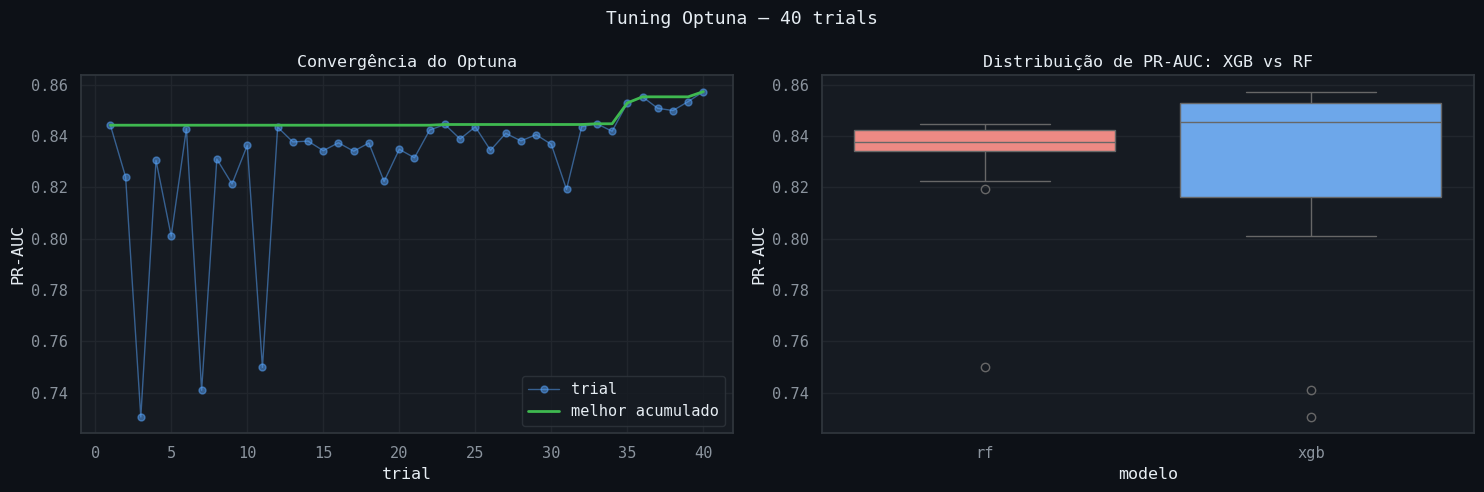

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Painel 1: histórico de otimização
valores = [t.value for t in estudo.trials if t.value is not None]
melhor_acum = np.maximum.accumulate(valores)

axes[0].plot(range(1, len(valores)+1), valores, "-o", color=PALETTE[0],
             alpha=0.5, markersize=5, linewidth=1, label="trial")
axes[0].plot(range(1, len(melhor_acum)+1), melhor_acum, color=CORES["verde"],
             linewidth=2, label="melhor acumulado")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("PR-AUC")
axes[0].set_title("Convergência do Optuna")
axes[0].legend()

# Painel 2: PR-AUC por tipo de modelo (boxplot)
td = estudo.trials_dataframe()

sns.boxplot(data=td, x="params_modelo", y="value",
            hue="params_modelo", palette=[PALETTE[1], PALETTE[0]],
            legend=False, ax=axes[1])
axes[1].set_xlabel("modelo"); axes[1].set_ylabel("PR-AUC")
axes[1].set_title("Distribuição de PR-AUC: XGB vs RF")

fig.suptitle("Tuning Optuna — 40 trials", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb04_optuna.png", dpi=120, bbox_inches="tight")
plt.show()

### Etapa 5 - Otimização do threshold (trade-off de negócio) 

Nesta etapa, o conjunto de teste será carregado para realizar a avaliação final do modelo vencedor.

In [12]:
X_test = pd.read_parquet(DADOS_PRO / "X_test.parquet")
y_test = pd.read_parquet(DADOS_PRO / "y_test.parquet").iloc[:, 0]

Após o carregamento, serão geradas as probabilidades preditas utilizando o método predict_proba. Para o problema de fraude, o foco será a probabilidade associada à classe positiva, ou seja, à classe fraude.

In [13]:
y_proba = pipeline_final.predict_proba(X_test)[:, 1]
y_proba

array([3.4592523e-07, 5.7396488e-07, 1.0740398e-06, ..., 1.0450007e-06,
       9.9179113e-07, 2.2512556e-07], dtype=float32)

In [14]:
pr_auc  = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

print("═" * 60)
print("DESEMPENHO NO TESTE (threshold-independente)")
print("═" * 60)

print(f"   PR-AUC  : {pr_auc:.4f}")
print(f"   ROC-AUC : {roc_auc:.4f}")

════════════════════════════════════════════════════════════
DESEMPENHO NO TESTE (threshold-independente)
════════════════════════════════════════════════════════════
   PR-AUC  : 0.8261
   ROC-AUC : 0.9741


Nesta etapa, será avaliada a **curva Precision-Recall** no conjunto de teste, utilizando as probabilidades estimadas pelo modelo vencedor.

A análise será dividida em três objetivos principais:

1. **Reportar o PR-AUC no teste**
   O **PR-AUC** será calculado sobre dados nunca vistos pelo modelo, fornecendo uma avaliação mais realista da capacidade de ranquear transações fraudulentas acima das legítimas. Essa métrica é independente de threshold e será usada como principal indicador de desempenho geral.

2. **Analisar thresholds candidatos**
   Serão avaliados diferentes pontos de corte para converter probabilidades em classes previstas, considerando objetivos distintos de negócio:

   * **Threshold 0,5**
     Ponto de corte padrão, utilizado como referência inicial.

   * **Threshold de máximo F1**
     Busca o melhor equilíbrio matemático entre **precision** e **recall**.

   * **Threshold de alto recall ≥ 95%**
     Estratégia mais agressiva, voltada para capturar quase todas as fraudes, mesmo que isso aumente o número de falsos positivos.

3. **Avaliar o trade-off operacional**
   A escolha do threshold não é apenas estatística. Em problemas de fraude, ela representa uma decisão de negócio entre:

   * aumentar o **recall**, reduzindo fraudes não detectadas;
   * preservar a **precision**, evitando excesso de alertas falsos em transações legítimas.

In [15]:
prec, rec, thr = precision_recall_curve(y_test, y_proba)

# F1 por threshold (equilíbrio) — e candidatos de negócio
f1s = 2 * (prec * rec) / (prec + rec + 1e-9)
idx_f1 = np.argmax(f1s)
thr_f1 = thr[idx_f1]

print("═" * 60)
print("THRESHOLDS CANDIDATOS")
print("═" * 60)

def avaliar(threshold, rotulo):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred)
    f = f1_score(y_test, y_pred)
    print(f"\n   {rotulo} (thr={threshold:.3f})")
    print(f"     Recall={r:.3f}  Precision={p:.3f}  F1={f:.3f}")
    print(f"     TP={tp}  FP={fp}  FN={fn}  TN={tn:,}")
    print(f"     → pega {tp}/{tp+fn} fraudes, {fp} falsos alarmes")
    return {"threshold": threshold, "recall": r, "precision": p, "f1": f,
            "tp": tp, "fp": fp, "fn": fn, "tn": tn}

res_05  = avaliar(0.5, "Threshold padrão")
res_f1  = avaliar(thr_f1, "Máximo F1")

# Threshold de alto recall (pegar 95%+ das fraudes)
idx_r95 = np.where(rec >= 0.95)[0]
thr_r95 = thr[idx_r95[-1]] if len(idx_r95) > 0 and idx_r95[-1] < len(thr) else thr[0]
res_r95 = avaliar(thr_r95, "Alto recall (>=95%)")
print()

════════════════════════════════════════════════════════════
THRESHOLDS CANDIDATOS
════════════════════════════════════════════════════════════

   Threshold padrão (thr=0.500)
     Recall=0.789  Precision=0.974  F1=0.872
     TP=75  FP=2  FN=20  TN=56,649
     → pega 75/95 fraudes, 2 falsos alarmes

   Máximo F1 (thr=0.264)
     Recall=0.811  Precision=0.951  F1=0.875
     TP=77  FP=4  FN=18  TN=56,647
     → pega 77/95 fraudes, 4 falsos alarmes

   Alto recall (>=95%) (thr=0.000)
     Recall=0.958  Precision=0.008  F1=0.015
     TP=91  FP=11608  FN=4  TN=45,043
     → pega 91/95 fraudes, 11608 falsos alarmes



Foram avaliados três pontos de corte para transformar probabilidades em classes previstas:

| Threshold | Estratégia  | Fraudes detectadas | Falsos positivos | Interpretação                                                        |
| --------: | ----------- | -----------------: | ---------------: | -------------------------------------------------------------------- |
| **0,500** | Padrão      |          **75/95** |            **2** | Conservador, com altíssima precisão, mas perde 20 fraudes            |
| **0,264** | Máximo F1   |          **77/95** |            **4** | Melhor equilíbrio entre recall e precision                           |
| **0,000** | Alto recall |          **91/95** |       **11.608** | Captura quase todas as fraudes, mas gera falsos positivos em excesso |

Dessa forma, o threshold de **máximo F1** se apresenta como a escolha mais equilibrada para o modelo final.

### Etapa 6 - Consolidação e visualização do threshold final

A escolha do threshold representa uma decisão de negócio, pois define o equilíbrio entre **capturar fraudes** e **evitar falsos alarmes em transações legítimas**.

O threshold de **máximo F1 = 0,264** foi selecionado como o ponto mais defensável para o modelo final. Em comparação ao threshold padrão de 0,5, ele captura mais fraudes, com aumento mínimo no número de falsos positivos:

* Threshold **0,5**: detecta **75 de 95 fraudes**, com **2 falsos positivos**;
* Threshold **0,264**: detecta **77 de 95 fraudes**, com **4 falsos positivos**.

Para consolidar a avaliação final, será gerado um painel com três visualizações principais:

1. **Matriz de confusão:**
   Avalia os acertos e erros do modelo no threshold escolhido.

2. **Curva Precision-Recall:**
   Mostra o trade-off entre precision e recall, sendo a curva mais relevante para problemas extremamente desbalanceados.

3. **Curva ROC:**
   Complementa a análise ao mostrar a separação geral entre classes, embora seja menos informativa que a PR Curve neste contexto.

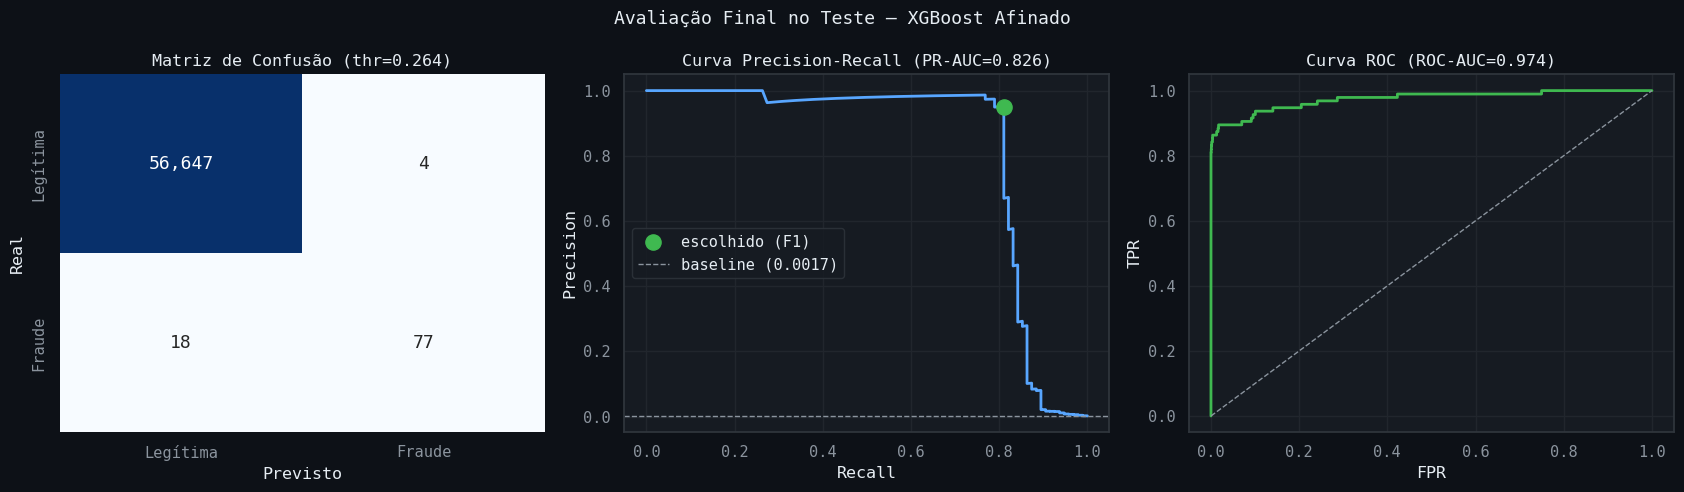

In [16]:
THRESHOLD_FINAL = float(thr_f1)   # 0.264 (máximo F1)
y_pred = (y_proba >= THRESHOLD_FINAL).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Legítima", "Fraude"],
            yticklabels=["Legítima", "Fraude"], ax=axes[0],
            annot_kws={"size": 13})
axes[0].set_title(f"Matriz de Confusão (thr={THRESHOLD_FINAL:.3f})")
axes[0].set_xlabel("Previsto"); axes[0].set_ylabel("Real")


axes[1].plot(rec, prec, color=PALETTE[0], linewidth=2)
axes[1].scatter(rec[idx_f1], prec[idx_f1], color=CORES["verde"], s=120,
                zorder=5, label=f"escolhido (F1)")
axes[1].axhline(y_test.mean(), color=CORES["texto2"], linestyle="--",
                linewidth=1, label=f"baseline ({y_test.mean():.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"Curva Precision-Recall (PR-AUC={pr_auc:.3f})")
axes[1].legend()


fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(fpr, tpr, color=PALETTE[2], linewidth=2)
axes[2].plot([0, 1], [0, 1], color=CORES["texto2"], linestyle="--", linewidth=1)
axes[2].set_xlabel("FPR"); axes[2].set_ylabel("TPR")
axes[2].set_title(f"Curva ROC (ROC-AUC={roc_auc:.3f})")

fig.suptitle("Avaliação Final no Teste — XGBoost Afinado", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "nb04_avaliacao.png", dpi=120, bbox_inches="tight")
plt.show()

* **Matriz de Confusão (**threshold = 0,264**)**

    * **77 fraudes detectadas**;
    * **18 fraudes não detectadas**;
    * apenas **4 falsos positivos** em **56.651 transações legítimas**.

* **Curva Precision-Recall**

    * A curva Precision-Recall evidencia claramente o ponto de equilíbrio do modelo. A precision permanece muito alta até aproximadamente **80% de recall**, mas sofre queda acentuada quando o modelo tenta capturar fraudes adicionais.

    * O threshold **0,264** está localizado justamente próximo ao “joelho” da curva, antes da perda expressiva de precision. Isso valida visualmente a escolha do ponto de corte: aumentar o recall além desse ponto exigiria aceitar um crescimento desproporcional de falsos positivos.

    * Essa análise sugere que o limite próximo de **80% de recall** não representa necessariamente uma falha do modelo, mas uma característica estrutural do problema. As fraudes restantes parecem ser mais difíceis de distinguir das transações legítimas sem comprometer fortemente a precisão.

* **Curva ROC**

    * A curva ROC apresenta formato próximo ao ideal, com **ROC-AUC de 0,974**, indicando boa separação geral entre as classes.

### Etapa 7 - Persistir artefatos e pipeline final

In [17]:
joblib.dump(pipeline_final, MODELS_DIR / "pipeline_final.joblib")
print(f"Pipeline Final salva em: models/pipeline_final.joblib")

Pipeline Final salva em: models/pipeline_final.joblib


In [18]:
metadados = {
    "modelo": "XGBoost",
    "threshold": THRESHOLD_FINAL,
    "pr_auc_cv": float(estudo.best_value),
    "pr_auc_teste": float(pr_auc),
    "roc_auc_teste": float(roc_auc),
    "recall_teste": float(recall_score(y_test, y_pred)),
    "precision_teste": float(precision_score(y_test, y_pred)),
    "f1_teste": float(f1_score(y_test, y_pred)),
    "hiperparametros": {k: v for k, v in estudo.best_params.items() if k != "modelo"},
    "scale_pos_weight": float(spw),
}
with open(MODELS_DIR / "metadados.json", "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

print(f"Metadados salvos em: models/metadados.json (threshold={THRESHOLD_FINAL:.3f})")

Metadados salvos em: models/metadados.json (threshold=0.264)


In [19]:
joblib.dump(estudo, MODELS_DIR / "estudo_optuna.pkl")

print(f"Estudo salvo: models/estudo_optuna.pkl")
print(f"Best value: {estudo.best_value:.4f} · Best trial: {estudo.best_trial.number}")

Estudo salvo: models/estudo_optuna.pkl
Best value: 0.8573 · Best trial: 39


### Etapa 8 - Fechamento

**OTIMIZAÇÃO (Optuna, 40 trials, TPESampler)**
* Busca conjunta XGBoost vs RandomForest (PR-AUC)
* Optuna deu 28 trials ao RF, 12 ao XGB — XGB venceu mesmo assim
* Vencedor: XGBoost · PR-AUC CV {estudo.best_value:.4f}
* HPs: n_est=526, max_depth=10, lr=0.094

**AVALIAÇÃO NO TESTE (intocado)**
* PR-AUC : {pr_auc:.4f}  (ROC-AUC {roc_auc:.4f} — enganoso aqui)
* Threshold otimizado: {THRESHOLD_FINAL:.3f} (máximo F1)

**RESULTADO FINAL (threshold {THRESHOLD_FINAL:.3f})**
* Recall    : {recall_score(y_test, y_pred):.3f}  (77 de 95 fraudes)
* Precision : {precision_score(y_test, y_pred):.3f}  (só 4 falsos alarmes)
* F1        : {f1_score(y_test, y_pred):.3f}
* Teto de recall ~80%: acima disso, precision colapsa (estrutura do problema)

**ARTEFATOS**
* models/pipeline_final.joblib (XGBoost afinado)
* models/metadados.json (threshold + métricas)
* reports/figures/nb04_optuna.png · nb04_avaliacao.png

**PRÓXIMO PASSO → NB05 (Interpretabilidade)**
* SHAP: quais features o XGBoost usa para detectar fraude
* Conectar com a EDA (V14, V4, V12 lideraram o Mann-Whitney)
* Casos: fraude bem detectada vs falso negativo